# Globular Cluster Stream

This example demonstrates how tambora can be used with [galpy](https://docs.galpy.org/en/stable/) to simulate the formation of a globular cluster tidal stream in the Milky Way.

## Setting up the simulation

In [1]:
from tambora.simulation import Sim

stream = Sim()

For the Milky Way, let's use the NFW component of galpy's [MWPotential2014](https://docs.galpy.org/en/latest/tutorials/potentials/milky_way_potentials.html#MWPotential2014) potential and add it to our simulation.

In [2]:
from galpy.potential import MWPotential2014
import astropy.units as u

# create MW potential
host = MWPotential2014[2]
host.turn_physical_on(ro=8*u.kpc, vo=220*u.km/u.s)

# add the potential to the simulation
stream.add_external_pot(host)

Next, we construct the progenitor by sampling **10,000** positions, velocities, and masses from a  $4 \times 10^4 \text{M}_{\odot}$ King sphere using tambora's initial condition routines with galpy under the hood. The progenitor's location is chosen to land it at the present location of GD-1 after 5 Gyr.

In [3]:
t_end = -5. * u.Gyr

from tambora.tools import galpy_orbit_to_tambora
import numpy as np

sat_mass = 4e4 * u.Msun # progenitor mass

from galpy.orbit import Orbit
ic_orb = Orbit.from_name('GD-1')
ic_orb.turn_physical_on()

ts_back = np.linspace(0, t_end, 100)
ic_orb.integrate(ts_back, host)
rtidal = host.rtide(R=ic_orb.R(t_end), z=ic_orb.z(t_end), M=sat_mass, quantity=True).to(u.kpc)

from tambora.tools import mkKing_galpy
pos, vel, mass = mkKing_galpy(m=sat_mass.value, n = 10_000, 
                              center_pos = [ic_orb.x(t_end).value, ic_orb.y(t_end).value, ic_orb.z(t_end).value],
                              center_vel = [ic_orb.vx(t_end).value, ic_orb.vy(t_end).value, ic_orb.vz(t_end).value],
                               W0=2, rt=rtidal.value)

In [4]:
print(f'Each particle has mass {np.mean(mass)} +/- {np.std(mass)} Msun')

Each particle has mass 4.0 +/- 0.0 Msun


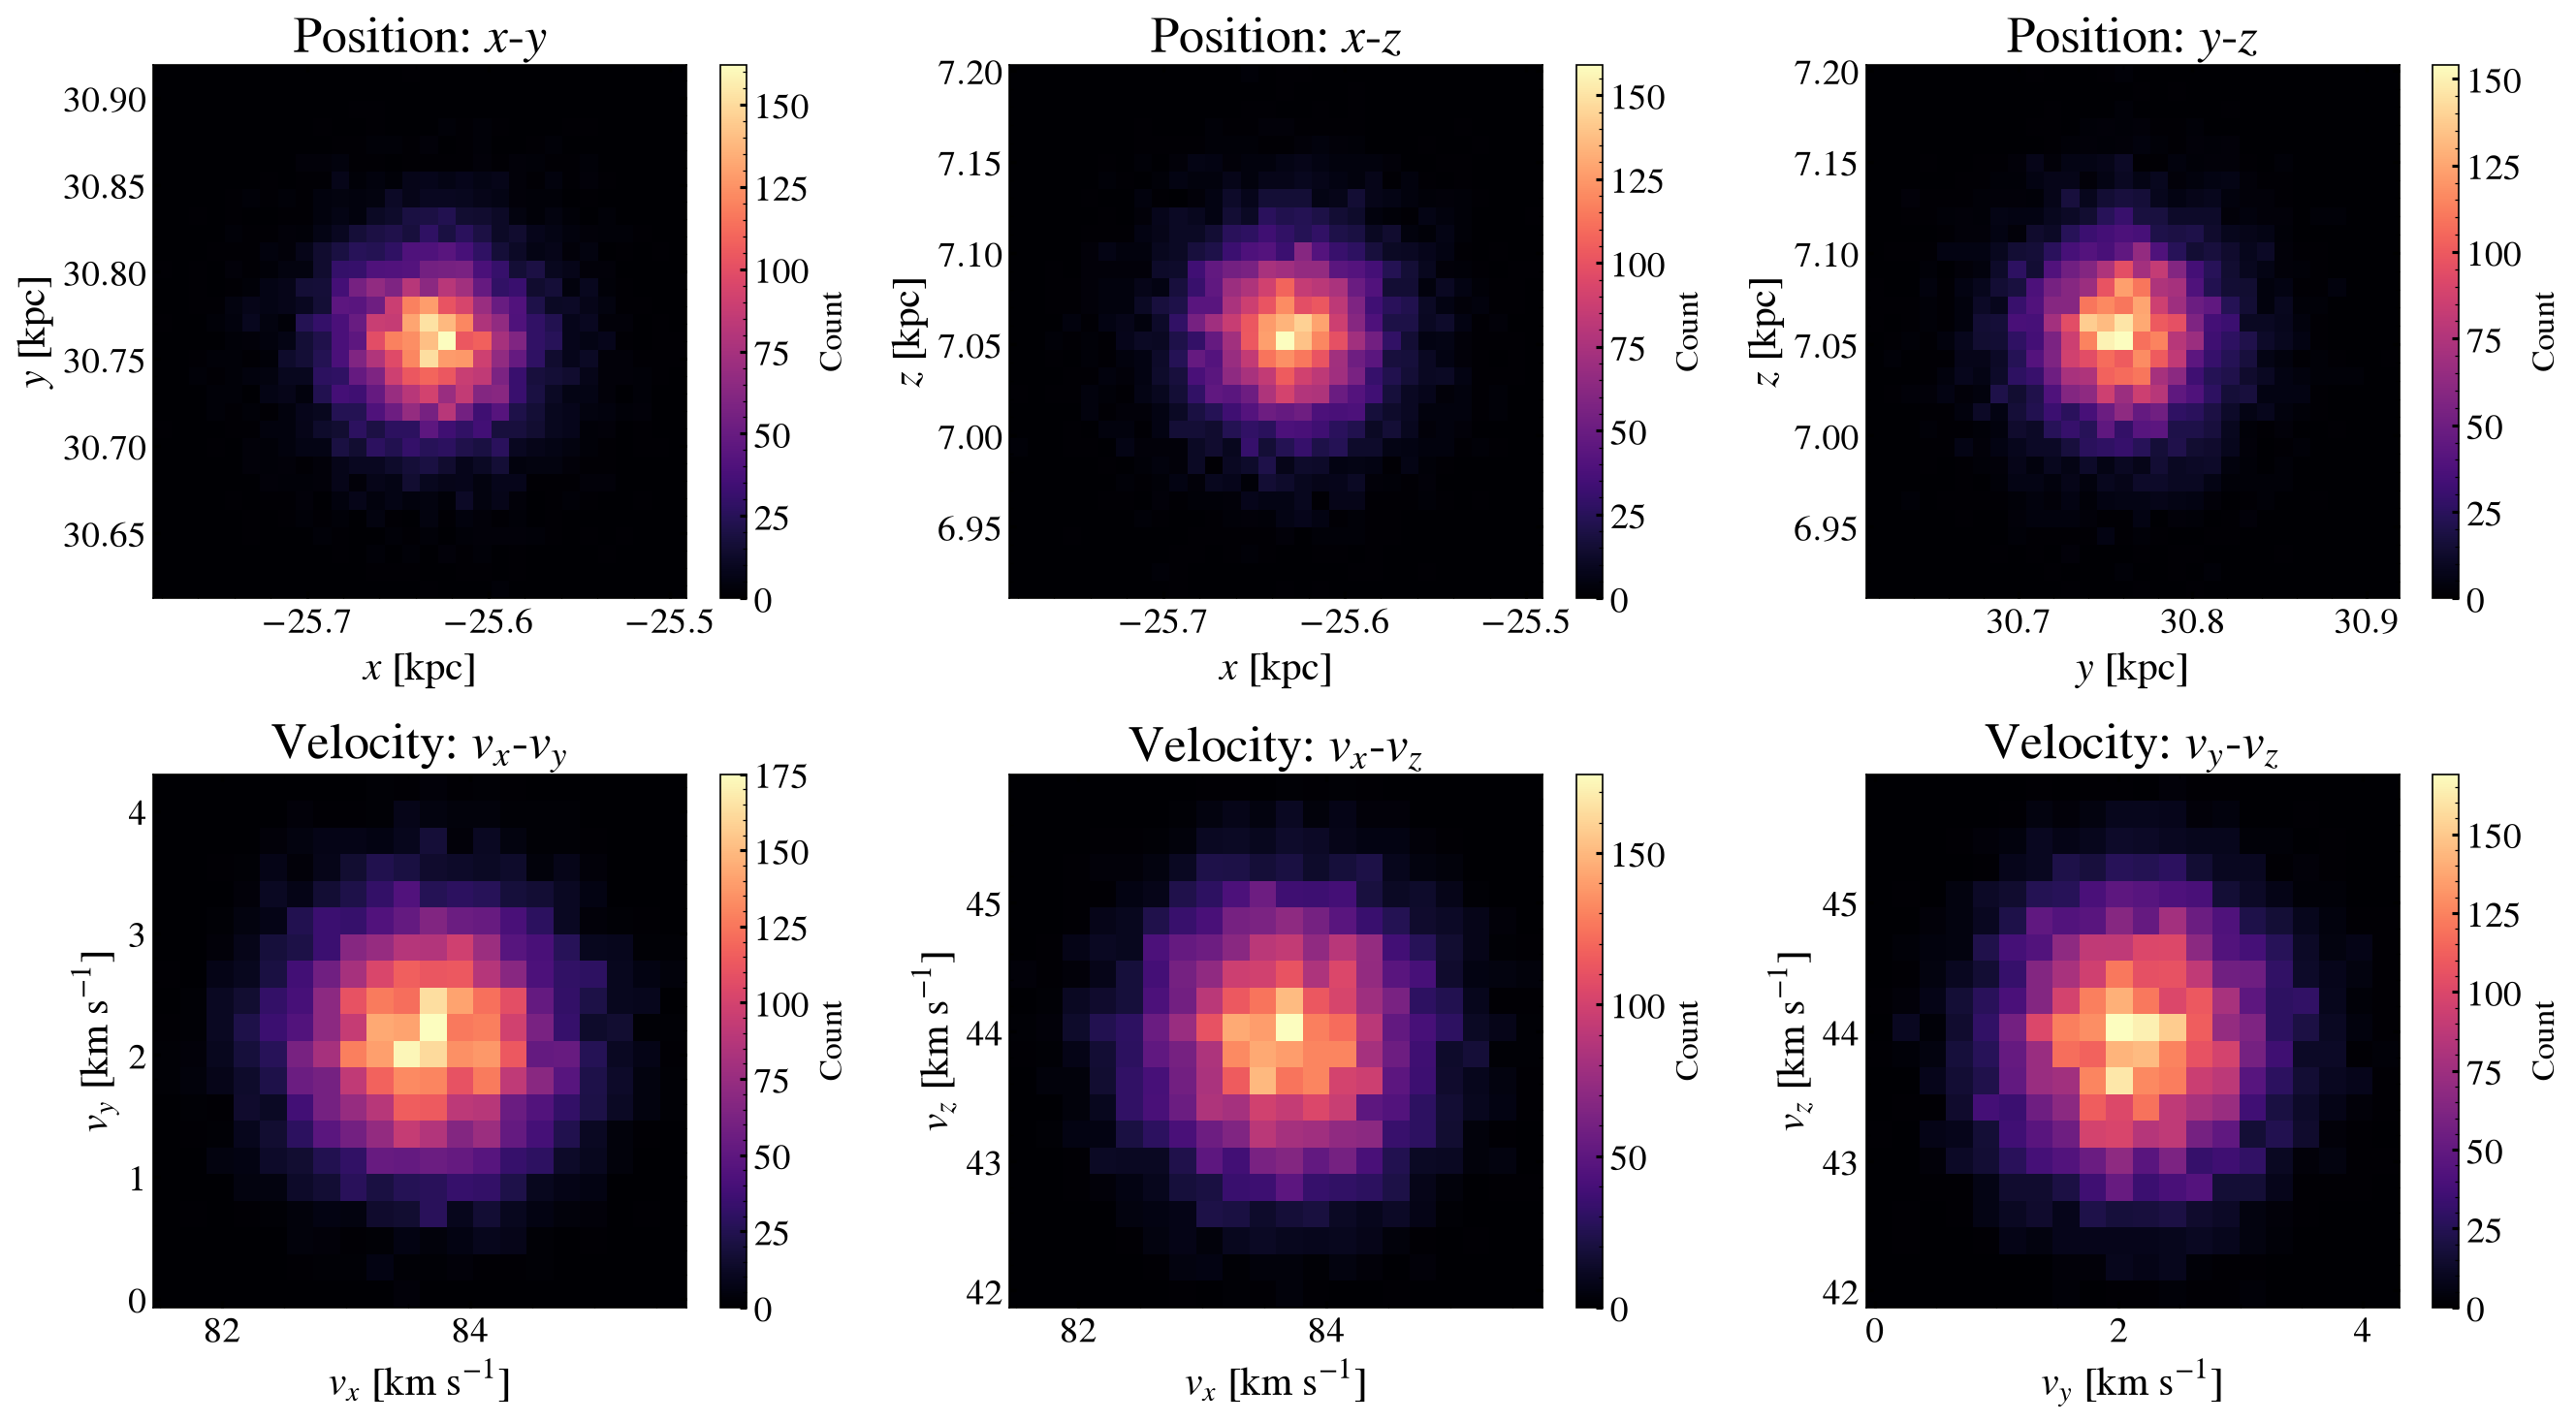

In [5]:
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=150)

# --- Top row: position projections ---
h_xy = axes[0, 0].hist2d(pos[:, 0], pos[:, 1], bins=30, cmap='magma')
axes[0, 0].set_xlabel(r'$x$ [kpc]', fontsize=20)
axes[0, 0].set_ylabel(r'$y$ [kpc]', fontsize=20)
axes[0, 0].set_title('Position: $x$-$y$', fontsize=25)
fig.colorbar(h_xy[3], ax=axes[0, 0], label='Count')

h_xz = axes[0, 1].hist2d(pos[:, 0], pos[:, 2], bins=30, cmap='magma')
axes[0, 1].set_xlabel(r'$x$ [kpc]', fontsize=20)
axes[0, 1].set_ylabel(r'$z$ [kpc]', fontsize=20)
axes[0, 1].set_title('Position: $x$-$z$', fontsize=25)
fig.colorbar(h_xz[3], ax=axes[0, 1], label='Count')

h_yz = axes[0, 2].hist2d(pos[:, 1], pos[:, 2], bins=30, cmap='magma')
axes[0, 2].set_xlabel(r'$y$ [kpc]', fontsize=20)
axes[0, 2].set_ylabel(r'$z$ [kpc]', fontsize=20)
axes[0, 2].set_title('Position: $y$-$z$', fontsize=25)
fig.colorbar(h_yz[3], ax=axes[0, 2], label='Count')

# --- Bottom row: velocity projections ---
h_vxvy = axes[1, 0].hist2d(vel[:, 0], vel[:, 1], bins=20, cmap='magma')
axes[1, 0].set_xlabel(r'$v_x$ [km s$^{-1}$]', fontsize=20)
axes[1, 0].set_ylabel(r'$v_y$ [km s$^{-1}$]', fontsize=20)
axes[1, 0].set_title('Velocity: $v_x$-$v_y$', fontsize=25)
fig.colorbar(h_vxvy[3], ax=axes[1, 0], label='Count')

h_vxvz = axes[1, 1].hist2d(vel[:, 0], vel[:, 2], bins=20, cmap='magma')
axes[1, 1].set_xlabel(r'$v_x$ [km s$^{-1}$]', fontsize=20)
axes[1, 1].set_ylabel(r'$v_z$ [km s$^{-1}$]', fontsize=20)
axes[1, 1].set_title('Velocity: $v_x$-$v_z$', fontsize=25)
fig.colorbar(h_vxvz[3], ax=axes[1, 1], label='Count')

h_vyvz = axes[1, 2].hist2d(vel[:, 1], vel[:, 2], bins=20, cmap='magma')
axes[1, 2].set_xlabel(r'$v_y$ [km s$^{-1}$]', fontsize=20)
axes[1, 2].set_ylabel(r'$v_z$ [km s$^{-1}$]', fontsize=20)
axes[1, 2].set_title('Velocity: $v_y$-$v_z$', fontsize=25)
fig.colorbar(h_vyvz[3], ax=axes[1, 2], label='Count')

fig.tight_layout()
plt.show()

And we add these particles to the simulation:

In [6]:
stream.add_particles('stars', pos=pos, vel=vel, mass=mass)
stream.components

(Component('stars', 10000 particles, 4.00e+04 Msun),)

We can compare the sampled density profile to the analytic profile:

/geir_data/scr/gabrielspace/tambora/.venv/lib/python3.12/site-packages/galpy/potential/SphericalPotential.py:50: RuntimeWarning: divide by zero encountered in divide
  return (self._r2deriv(r, t=t) - 2.0 * self._rforce(r, t=t) / r) / 4.0 / numpy.pi



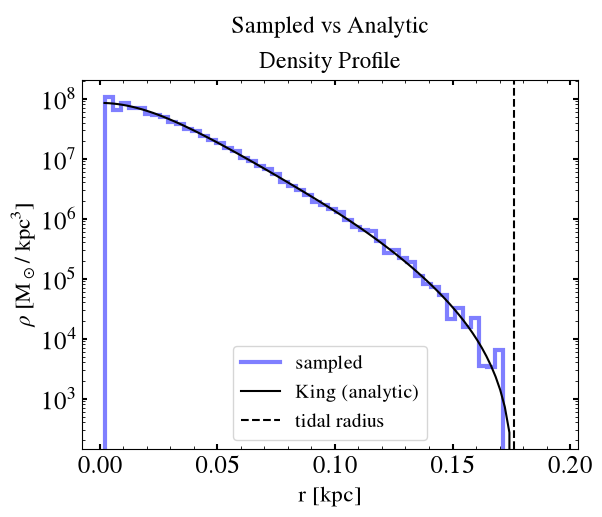

In [7]:
from galpy.potential import KingPotential

kingpot = KingPotential(M=sat_mass, W0=2, rt=rtidal)

# 3D distance of each star from the cluster center
cen = np.median(stream.stars.pos(0), axis=0)
d   = np.linalg.norm(stream.stars.pos(0) - cen, axis=1)

# counts -> volume density via shell volumes
counts, bins = np.histogram(d, bins=50)
r_mid = 0.5 * (bins[:-1] + bins[1:])
shell_vol = 4 * np.pi * r_mid**2 * np.diff(bins)
rho = counts * np.mean(mass) / shell_vol           # M⊙ / kpc^3

rlist = np.linspace(0, 1.1 * rtidal.value, 100) * u.kpc
plt.stairs(rho, bins, color='blue', linewidth=3, label='sampled', alpha=0.5)
plt.plot(rlist, kingpot.dens(rlist, z=0, quantity=True).to(u.Msun / u.kpc**3),
         label='King (analytic)', c='k')
plt.axvline(rtidal.value, ls='--', c='k', label='tidal radius')
plt.xlabel('r [kpc]'); plt.ylabel(r'$\rho$ [M$_\odot$/ kpc$^3$]')
plt.yscale('log'); plt.legend()
plt.title('Sampled vs Analytic\nDensity Profile')
plt.show()

With the particles added, we can do all sorts of fun things like visualize the self-gravity and external forces/accelerations using the helpful accessor methods of {class}`~tambora.simulation.Sim`.

In [8]:
# --- Positions ---------------------------------------- #
xpos = stream.x(0)
ypos = stream.y(0)

# --- Self-Gravity Accelerations ----------------------- #
x_self_acc = stream.self_ax(0, method='falcON', eps=0.01)
y_self_acc = stream.self_ay(0, method='falcON', eps=0.01)

# --- External Field Accelerations --------------------- #
x_ext_acc = stream.external_ax(0)
y_ext_acc = stream.external_ay(0)

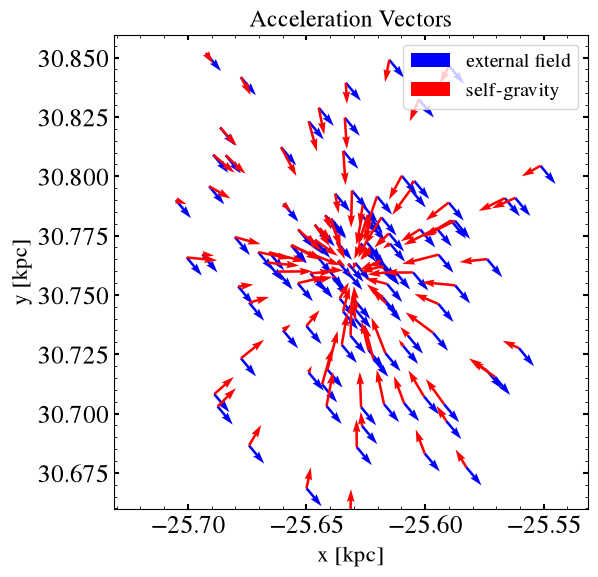

In [9]:
skip_every = 80
fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(stream.x(0)[::skip_every], stream.y(0)[::skip_every], 
          stream.external_ax(0)[::skip_every], stream.external_ay(0)[::skip_every], 
          alpha=1, color='b', label='external field')
ax.quiver(stream.x(0)[::skip_every], stream.y(0)[::skip_every], 
          stream.self_ax(0, method='falcON', eps=0.01)[::skip_every], 
          stream.self_ay(0, method='falcON', eps=0.01)[::skip_every], 
          alpha=1, color='r', label='self-gravity')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_title('Acceleration Vectors')
ax.set_aspect('equal')
plt.tight_layout()
plt.xlim(ic_orb.x(t_end).value - 0.1, ic_orb.x(t_end).value + 0.1)
plt.ylim(ic_orb.y(t_end).value - 0.1, ic_orb.y(t_end).value + 0.1)
plt.legend()

plt.show()

## Running the simulation

Let's add a hook to track which particles are bound/unbound at sub-snapshot time resolution. In this case, boundedness will be calculated every other (internal) step.

In [10]:
from tambora.dynamics.hooks import BoundednessHook, EveryNSteps

bh = BoundednessHook('stars', eps=0.0015, track=('com', 'com_vel'))
stream.add_hook(bh, EveryNSteps(2))

Next, the `run` method evolves the particles under the influence of self-gravity and the external potential for **5.0 Gyr**. I elect to compute self-gravity with `falcON` here.

Runs in **~7 minutes**

In [ ]:
stream.run(t_end = 5.0, dt = 0.0005, dt_out=0.01, method='falcON', eps=0.0015)

  0%|          | 0/10000 [00:00<?, ?it/s]

  7%|▋         | 741/10000 [00:36<11:50, 13.03it/s, n_bound(stars)=9854, |dE/E0|=1.70e-07]

Anddd, **it's a stream!**

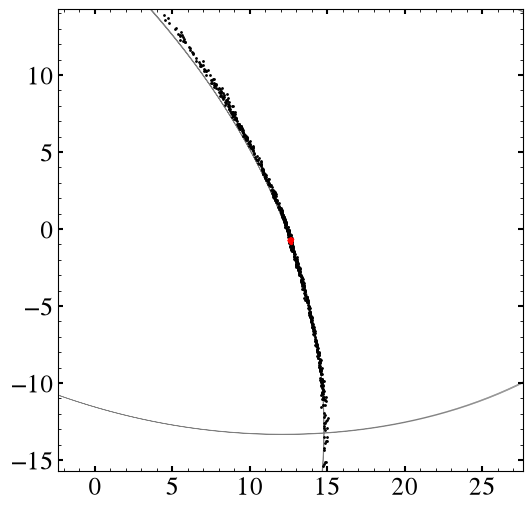

In [ ]:
t_ind = -1
skip = 10

bnd = bh.mask_at(stream.times[t_ind])

com = np.array(bh.com)
plt.figure(figsize=(6,6))
plt.plot(com[:,0], com[:, 1], c='k', alpha=0.5, lw=0.5, zorder=0)

plt.scatter(stream.x(t_ind)[~bnd][::skip], stream.y(t_ind)[~bnd][::skip], c='k',alpha=1., s=1)
plt.scatter(stream.x(t_ind)[bnd][::skip], stream.y(t_ind)[bnd][::skip], s=2, alpha=1, c='r')
com_t_ind = np.argmin(np.abs(stream.times[t_ind] - bh.t))
plt.xlim(com[com_t_ind][0] - 15, com[com_t_ind][0] + 15)
plt.ylim(com[com_t_ind][1] - 15, com[com_t_ind][1] + 15)
plt.xlabel
plt.show()

Since we have the boundedness hook, we have access to the precise path of the satellite's bound center of mass and the times that particles became unbound. We can see that, as expected, particles are stripped in a skew-symmetric distribution around pericenter.

In [ ]:
from scipy.signal import argrelmin

# find time of prog. pericenters
prog_com_r = np.linalg.norm(np.array(bh.com), axis=-1)
peri_inds = argrelmin(prog_com_r)[0]
peri_ts = [bh.t[peri_ind] for peri_ind in peri_inds]

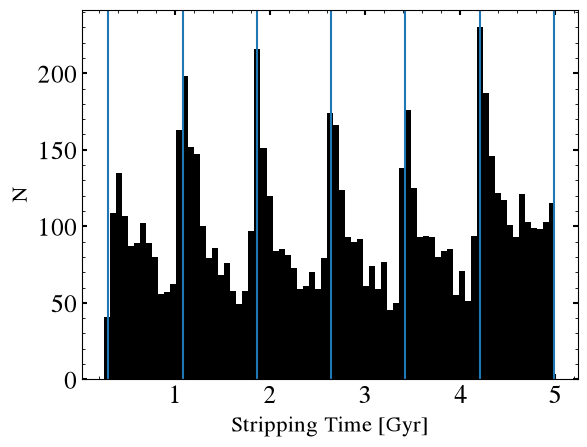

In [ ]:
mask = bh.mask_at(stream.times[t_ind])
t_rls = bh.release_time(stream.times[t_ind])[~mask]

plt.hist(t_rls, color='k', bins=75)
[plt.axvline(peri_t) for peri_t in peri_ts]
plt.xlabel('Stripping Time [Gyr]')
plt.ylabel('N')
plt.show()

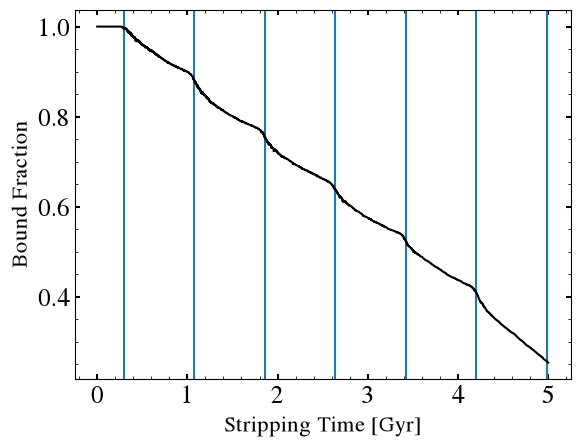

In [ ]:
[plt.axvline(peri_t) for peri_t in peri_ts]
plt.plot(bh.t, bh.fraction(), c='k')
plt.xlabel('Stripping Time [Gyr]')
plt.ylabel('Bound Fraction')
plt.show()

## Analysing the Stream with `galpy`

In [ ]:
from galpy.orbit import Orbit
from galpy.util import coords, conversion
from tambora.tools.util.units import KPCGYR_TO_KMS

ro, vo, zo = 8., 220., 0.0208          # zo = galpy's default solar height

bnd = bh.mask_at(stream.times[t_ind])

# --- the progenitor's orbit, from the bound remnant's *present* phase space ---
# bh.com/bh.com_vel are in INTERNAL units (kpc, kpc/Gyr), so the velocity needs
# converting to km/s before galpy sees it.
com, com_vel = np.array(bh.com), np.array(bh.com_vel)
com
c_now, v_now = com[com_t_ind], com_vel[com_t_ind] * KPCGYR_TO_KMS

R, phi, z = coords.rect_to_cyl(*c_now)
vR, vT, vz = coords.rect_to_cyl_vec(*v_now, *c_now, cyl=False)
prog = Orbit([R*u.kpc, vR*u.km/u.s, vT*u.km/u.s, z*u.kpc, vz*u.km/u.s, phi*u.rad],
             ro=ro, vo=vo)

# The 3x3 rotation from (ra, dec) into the stream frame. phi1 runs along the
# progenitor's orbit, phi2 perpendicular to it; the progenitor sits at phi1=180
# by default, which keeps us away from the 0/360 wrap.
rot = prog.align_to_orbit()

print(f"progenitor: R = {R:.2f} kpc, {prog.dist(quantity=False):.1f} kpc from the Sun")
print(f"in its own frame: phi1 = {prog.phi1(quantity=False):.1f} deg, "
      f"phi2 = {prog.phi2(quantity=False):.2f} deg")

progenitor: R = 12.65 kpc, 7.6 kpc from the Sun
in its own frame: phi1 = 180.0 deg, phi2 = 0.00 deg


In [ ]:
from galpy.potential import evaluatePotentials

# --- the spine the debris gets projected onto -------------------------------
# from_particles needs the progenitor orbit sampled on BOTH sides of tp=0: the
# leading arm lives at tp>0 and the trailing arm at tp<0, so integrate the
# progenitor forwards and backwards and stitch the two halves together.
#
# T_span must be long enough for the spine to reach the far end of the debris --
# if the fitted track stops short of the tails, lengthen it.
T_span, n = 0.7, 400                                  # Gyr each way
tf, tb = np.linspace(0, T_span, n)*u.Gyr, np.linspace(0, -T_span, n)*u.Gyr
o_fwd, o_bwd = prog(), prog()
o_fwd.integrate(tf, host)
o_bwd.integrate(tb, host)

def _cart(o, ts):
    return np.array([o.x(ts, quantity=False), o.y(ts, quantity=False), o.z(ts, quantity=False),
                     o.vx(ts, quantity=False), o.vy(ts, quantity=False), o.vz(ts, quantity=False)]).T

prog_cart = np.vstack([_cart(o_bwd, tb)[::-1][:-1], _cart(o_fwd, tf)])   # (M, 6), monotonic in tp
t_gyr = np.concatenate([np.linspace(-T_span, 0, n)[:-1], np.linspace(0, T_span, n)])

# from_particles wants galpy INTERNAL units
prog_cart_int = prog_cart / np.array([ro, ro, ro, vo, vo, vo])
t_int = t_gyr / conversion.time_in_Gyr(vo, ro)

# --- debris -> galpy's (R, vR, vT, z, vz, phi) ------------------------------
p, v = stream.stars.pos(t_ind)[~bnd], stream.stars.vel(t_ind)[~bnd]
Rd, phid, zd = coords.rect_to_cyl(p[:, 0], p[:, 1], p[:, 2])
vRd, vTd, vzd = coords.rect_to_cyl_vec(v[:, 0], v[:, 1], v[:, 2],
                                       p[:, 0], p[:, 1], p[:, 2], cyl=False)
xv = np.array([Rd/ro, vRd/vo, vTd/vo, zd/ro, vzd/vo, phid])      # (6, N), internal

# --- split the arms: leading debris sits at lower energy than the progenitor -
_pot = lambda R_, z_: evaluatePotentials(host, R_*u.kpc, z_*u.kpc,
                                         quantity=True).to(u.km**2/u.s**2).value
E_debris = 0.5*(vRd**2 + vTd**2 + vzd**2) + _pot(Rd, zd)
E_prog = 0.5*np.sum(v_now**2) + _pot(R, z)
lead = E_debris < E_prog

print(f"spine: {prog_cart_int.shape[0]} points, tp in [{t_int.min():.1f}, {t_int.max():.1f}]")
print(f"leading: {lead.sum()}   trailing: {(~lead).sum()}")

spine: 799 points, tp in [-19.7, 19.7]
leading: 3731   trailing: 3731


In [ ]:
from galpy.df import StreamTrack

# One track per arm. Passing custom_sky_transform lets the track report itself in
# (phi1, phi2) directly. solarmotion must be a 3-vector here (the string aliases
# Orbit accepts are not supported).
tracks = {
    name: StreamTrack.from_particles(
        xv[:, sel], track_prog_cart=prog_cart_int, track_t_grid=t_int,
        arm_sign=sign, custom_sky_transform=rot,
        ro=ro, vo=vo, zo=zo, solarmotion=[-11.1, 12.24, 7.25])
    for name, sel, sign in (('leading', lead, +1), ('trailing', ~lead, -1))
}

def to_phi12(xyz):
    """Galactocentric cartesian [kpc] -> stream-frame (phi1, phi2) [deg].

    This is the vectorised version of Orbit.phi1/phi2 (agrees to ~1e-5 deg), so
    it is cheap enough to run on every particle at every snapshot.
    """
    X, Y, Z = coords.galcenrect_to_XYZ(xyz[..., 0], xyz[..., 1], xyz[..., 2],
                                       Xsun=ro, Zsun=zo).T
    l, b, _ = coords.XYZ_to_lbd(X, Y, Z, degree=True).T
    ra, dec = coords.lb_to_radec(l, b, degree=True).T
    return coords.radec_to_custom(ra, dec, T=rot, degree=True).T

phi1, phi2 = to_phi12(p)
print(f"debris phi1: {phi1.min():.0f} .. {phi1.max():.0f} deg"
      f"   phi2: {phi2.min():.1f} .. {phi2.max():.1f} deg")

debris phi1: 94 .. 262 deg   phi2: -6.4 .. 1.0 deg


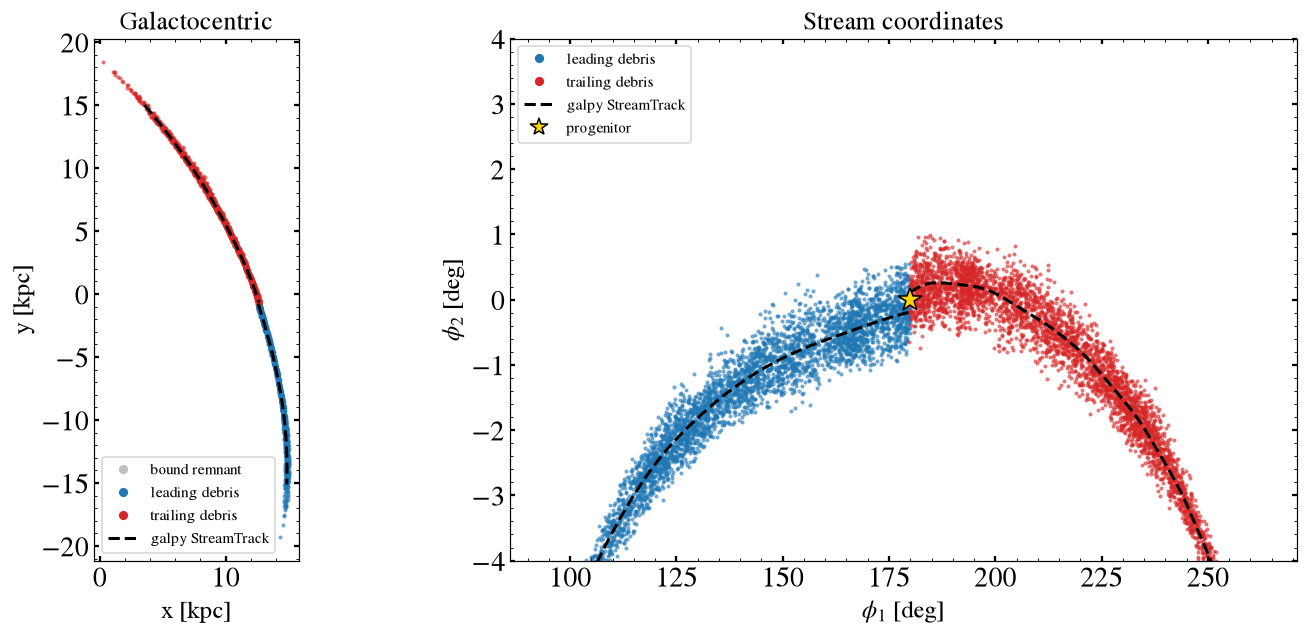

In [ ]:
from matplotlib.lines import Line2D

def supported(tr, sel, rmax=1.0):
    """The stretch of track that actually has particles near it.

    from_particles will happily spline across a gap in tp where no debris lives
    (galpy warns when it spots one), which shows up as a straight chord through
    empty space. So keep only tp whose track point is within `rmax` kpc of some
    particle, then take the contiguous run through the progenitor at tp=0.
    """
    tp = tr.tp_grid()
    txyz = np.array([tr.x(tp, quantity=False), tr.y(tp, quantity=False),
                     tr.z(tp, quantity=False)]).T
    ok = np.sqrt(((txyz[:, None, :] - p[sel][None, :, :])**2).sum(-1)).min(1) < rmax
    i0 = np.argmin(np.abs(tp))
    if not ok[i0]:
        return tp[ok]
    lo = hi = i0
    while lo > 0 and ok[lo-1]:
        lo -= 1
    while hi < len(tp)-1 and ok[hi+1]:
        hi += 1
    return tp[lo:hi+1]

colour = {'leading': 'tab:blue', 'trailing': 'tab:red'}
fig, ax = plt.subplots(1, 2, figsize=(14, 6), dpi=110)

ax[0].scatter(stream.stars.pos(t_ind)[bnd, 0], stream.stars.pos(t_ind)[bnd, 1],
              s=1, c='0.75')
for name, sel in (('leading', lead), ('trailing', ~lead)):
    tp = supported(tracks[name], sel)
    ax[0].scatter(p[sel, 0], p[sel, 1], s=3, c=colour[name], alpha=.5)
    ax[0].plot(tracks[name].x(tp, quantity=False), tracks[name].y(tp, quantity=False),
               'k--', lw=2, zorder=5)
    ax[1].scatter(phi1[sel], phi2[sel], s=3, c=colour[name], alpha=.5)
    ax[1].plot(tracks[name].phi1(tp, quantity=False), tracks[name].phi2(tp, quantity=False),
               'k--', lw=2, zorder=5)

ax[1].plot(prog.phi1(quantity=False), prog.phi2(quantity=False), '*',
           ms=16, c='gold', mec='k', zorder=6)

handles = [Line2D([], [], ls='', marker='o', ms=5, c='0.75', label='bound remnant'),
           Line2D([], [], ls='', marker='o', ms=5, c='tab:blue', label='leading debris'),
           Line2D([], [], ls='', marker='o', ms=5, c='tab:red', label='trailing debris'),
           Line2D([], [], ls='--', lw=2, c='k', label='galpy StreamTrack')]
ax[0].legend(handles=handles, fontsize=10)
ax[0].set(xlabel='x [kpc]', ylabel='y [kpc]', title='Galactocentric')
ax[0].set_aspect('equal')

ax[1].legend(handles=handles[1:] + [Line2D([], [], ls='', marker='*', ms=12, c='gold',
                                           mec='k', label='progenitor')],
             fontsize=10, loc='upper left')
ax[1].set(xlabel=r'$\phi_1$ [deg]', ylabel=r'$\phi_2$ [deg]',
          title='Stream coordinates', ylim=(-4, 4))
plt.tight_layout()
plt.show()

We can explore the stream in action-angle coordinates using galpy's convenient tools for action, angle, and frequency calculation.

In [ ]:
o_unbnd = Orbit(xv.T)
o_unbnd.turn_physical_on(ro=ro, vo=vo)

In [ ]:
from galpy.actionAngle import actionAngleStaeckel
aAI = actionAngleStaeckel(pot=host, c=True, fixed_quad=True, delta=0.25)
aAI.turn_physical_on()

(jr, jp, jz, 
Or, Op, Oz, 
tr, tp, tz) = aAI.actionsFreqsAngles(o_unbnd)

(progjr, progjp, progjz, 
 progOr, progOp, progOz, 
 progtr, progtp, progtz) = aAI.actionsFreqsAngles(prog)

In [ ]:
tr = (tr.value + np.pi)%(2*np.pi)
tp = (tp.value + np.pi)%(2*np.pi)
tz = (tz.value + np.pi)%(2*np.pi)

progtr = (progtr.value + np.pi)%(2*np.pi)
progtp = (progtp.value + np.pi)%(2*np.pi)
progtz = (progtz.value + np.pi)%(2*np.pi)

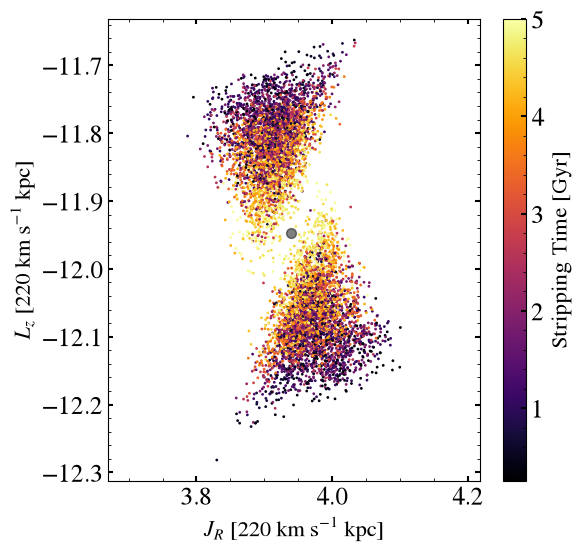

In [ ]:
plt.figure(figsize=(6,6))
p = plt.scatter(jr/220, jp/220, s=1, c=t_rls, cmap='inferno')
plt.colorbar(p, label='Stripping Time [Gyr]')
plt.scatter(progjr/220, progjp/220, s=50, c='k', alpha=0.5)
plt.axis('equal')
plt.xlabel('$J_R$ [220 km s$^{-1}$ kpc]')
plt.ylabel('$L_z$ [220 km s$^{-1}$ kpc]')
plt.show()

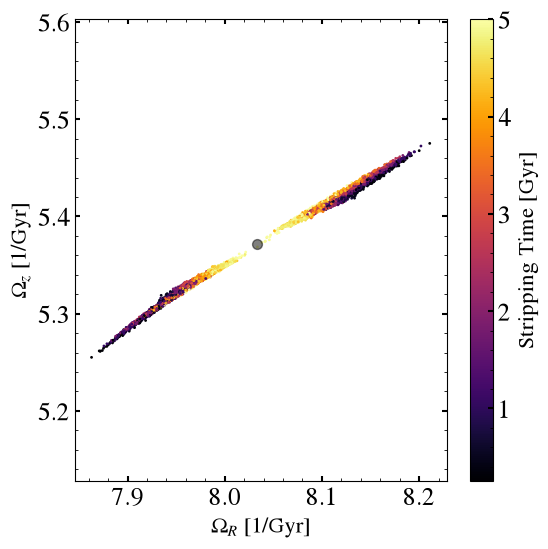

In [ ]:
plt.figure(figsize=(6,6))
p = plt.scatter(Or, Oz, s=1., c=t_rls, cmap='inferno')
plt.colorbar(p, label='Stripping Time [Gyr]')
plt.scatter(progOr, progOz, s=50, c='k', alpha=0.5)
plt.xlabel('$\\Omega_R$ [1/Gyr]')
plt.ylabel('$\\Omega_z$ [1/Gyr]')
plt.axis('equal')
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\p'

<>:6: SyntaxWarning: invalid escape sequence '\p'

/tmp/ipykernel_3287127/974217465.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\\Omega_{\phi}$ [1/Gyr]')



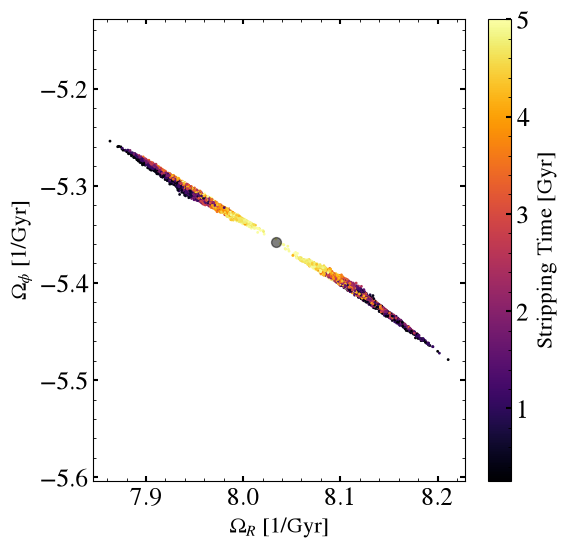

In [ ]:
plt.figure(figsize=(6,6))
p = plt.scatter(Or, Op, s=1., c=t_rls, cmap='inferno')
plt.colorbar(p, label='Stripping Time [Gyr]')
plt.scatter(progOr, progOp, s=50, c='k', alpha=0.5)
plt.xlabel('$\\Omega_R$ [1/Gyr]')
plt.ylabel('$\\Omega_{\phi}$ [1/Gyr]')
plt.axis('equal')
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\p'

<>:6: SyntaxWarning: invalid escape sequence '\p'

/tmp/ipykernel_3287127/669217952.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\\theta_{\phi}$')



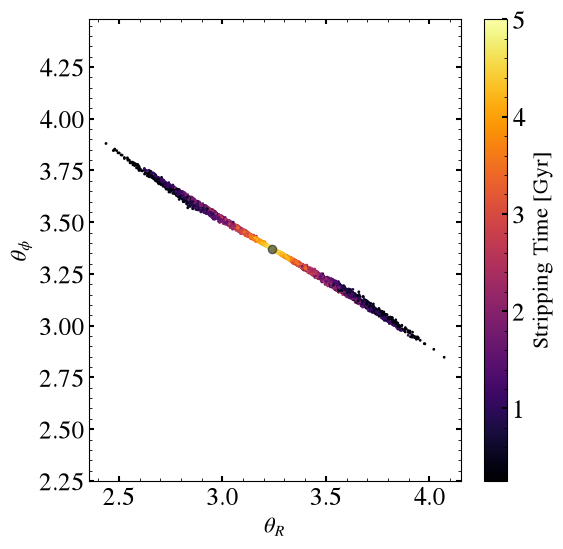

In [ ]:
plt.figure(figsize=(6,6))
p = plt.scatter(tr, tp, s=1., c=t_rls, cmap='inferno')
plt.colorbar(p, label='Stripping Time [Gyr]')
plt.scatter(progtr, progtp, c='k', alpha=0.5)
plt.xlabel('$\\theta_R$')
plt.ylabel('$\\theta_{\phi}$')
plt.axis('equal')
plt.show()

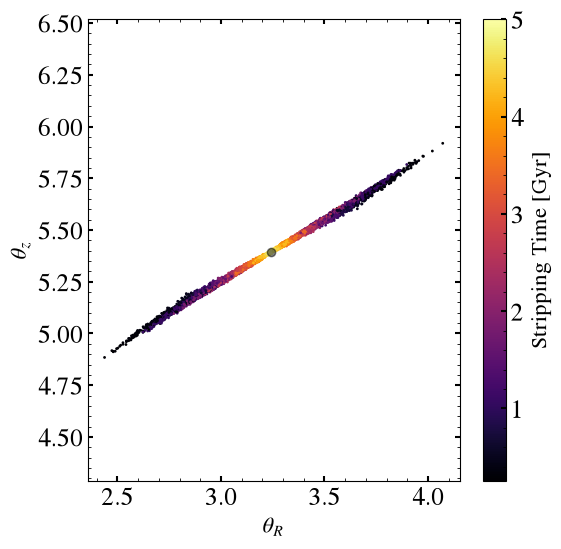

In [ ]:
plt.figure(figsize=(6,6))
p = plt.scatter(tr, tz, s=1., c=t_rls, cmap='inferno')#
plt.colorbar(p, label='Stripping Time [Gyr]')
plt.scatter(progtr, progtz, c='k', alpha=0.5)
plt.xlabel('$\\theta_R$')
plt.ylabel('$\\theta_z$')
plt.axis('equal')
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\l'

<>:12: SyntaxWarning: invalid escape sequence '\l'

/tmp/ipykernel_3287127/1198959947.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$ \left| \\Delta \\Omega_{\\parallel} \\right|$')



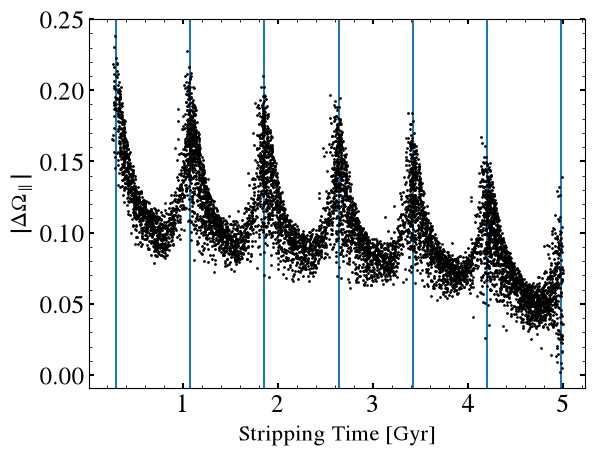

In [ ]:
O_vec = np.array([Or, Op, Oz]).T
O_ref = np.array([progOr, progOp, progOz]).T

_, _, Vt = np.linalg.svd(O_vec - O_ref, full_matrices=False)
d_hat = Vt[0]

dO = np.abs(np.dot(O_vec - O_ref, d_hat))

[plt.axvline(peri_t) for peri_t in peri_ts]
plt.scatter(t_rls, dO, s=1, c='k', zorder=100)
plt.xlabel('Stripping Time [Gyr]')
plt.ylabel('$ \left| \\Delta \\Omega_{\\parallel} \\right|$')
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\l'

<>:12: SyntaxWarning: invalid escape sequence '\l'

/tmp/ipykernel_3287127/2420648658.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$ \left| \\Delta \\theta_{\\parallel} \\right|$')



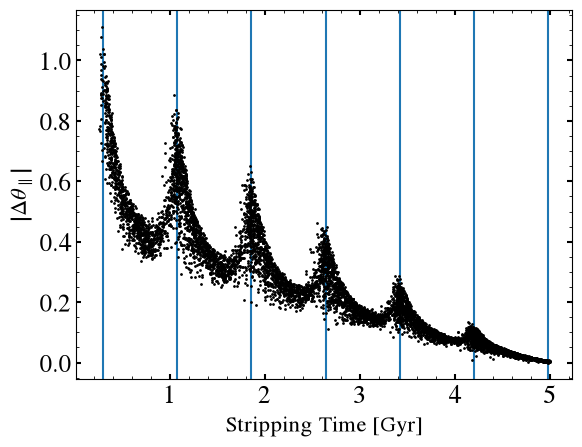

In [ ]:
t_vec = np.array([tr, tp, tz]).T
t_ref = np.array([progtr, progtp, progtz]).T

_, _, Vt = np.linalg.svd(t_vec - t_ref, full_matrices=False)
d_hat = Vt[0] 

dth = np.abs(np.dot(t_vec - t_ref, d_hat))

[plt.axvline(peri_t) for peri_t in peri_ts]
plt.scatter(t_rls, dth, s=1, c='k', zorder=100)
plt.xlabel('Stripping Time [Gyr]')
plt.ylabel('$ \left| \\Delta \\theta_{\\parallel} \\right|$')
plt.show()

## Checking Performance

We can check how well energy is conserved in a few different ways. We can check using the values calculated during integration (fastest):

/geir_data/scr/gabrielspace/tambora/tambora/simulation/simulation.py:1289: UserWarning: Computing external potential on-the-fly for multiple snapshots may be slow.
  warnings.warn("Computing external potential on-the-fly for multiple snapshots may be slow.")



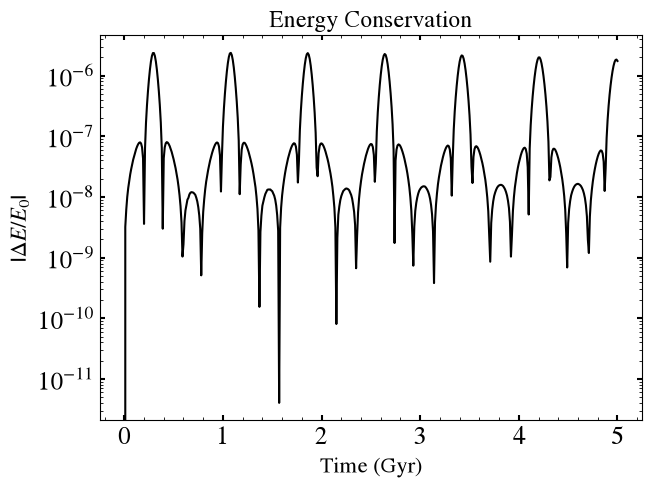

In [ ]:
stream.plot_energy_diagnostic()

We can also check conservation of energy with a different method for calculating the self-gravity potential that is more precise (direct summation, slower). This allows us to ensure 

/geir_data/scr/gabrielspace/tambora/tambora/simulation/simulation.py:1880: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')



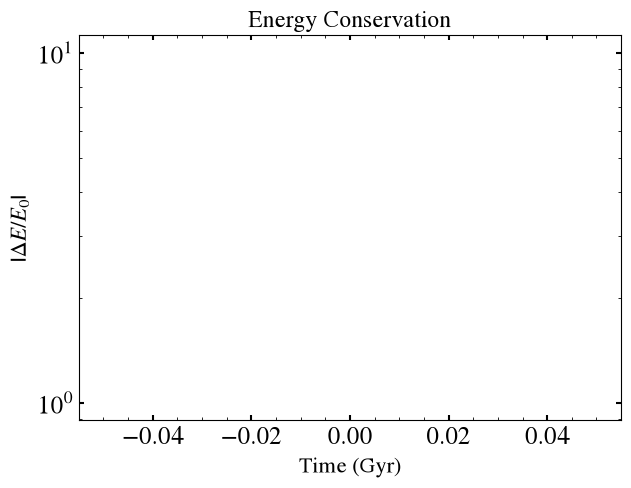

In [ ]:
# direct summation is expensive, so only 
# calculate at 5 snapshots. Runs in ~5.5 minutes

stream.plot_energy_diagnostic(method='direct_C', eps=0.01, nsnap=5)